Forme du dataset chargé : (51000, 12)
Fraudulent
0    48490
1     2510
Name: count, dtype: int64
Après SMOTE, comptes : [38792 38792]
Précision : 0.062370062370062374
Rappel : 0.11952191235059761
AUC : 0.5235726510333177
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      9698
           1       0.06      0.12      0.08       502

    accuracy                           0.87     10200
   macro avg       0.51      0.51      0.51     10200
weighted avg       0.91      0.87      0.89     10200

Matrice de confusion :
 [[8796  902]
 [ 442   60]]


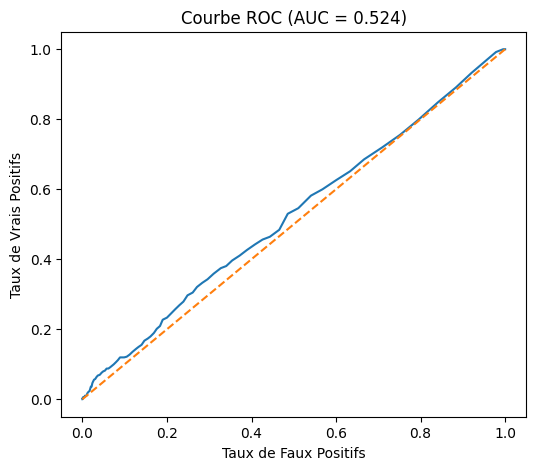

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Charger les données
df = pd.read_csv('Fraud Detection Dataset.csv')  # changer le nom du fichier si nécessaire
print('Forme du dataset chargé :', df.shape)
print(df['Fraudulent'].value_counts())

# Basic preprocessing: separate X and y
y = df['Fraudulent']
X = df.drop(columns=['Fraudulent'])

# Impute missing values
for col in X.columns:
    if X[col].isnull().any():
        if X[col].dtype in ['int64', 'float64']:
            X[col] = X[col].fillna(X[col].mean())
        else:
            X[col] = X[col].fillna(X[col].mode()[0])

# Encode categorical cols (simple)
for col in X.select_dtypes(include=['object','category']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE on training set
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    print('Après SMOTE, comptes :', np.bincount(y_res.astype(int)))
except Exception as e:
    print('imblearn non disponible. Utilisation d\'une implémentation manuelle simple de SMOTE. Erreur :', e)
    # Simple manual SMOTE (vector interpolation)
    from sklearn.neighbors import NearestNeighbors
    X_train_np = X_train.values
    y_train_np = y_train.values
    minority_idx = np.where(y_train_np==1)[0]
    X_min = X_train_np[minority_idx]

    # Impute missing values in X_min before fitting NearestNeighbors
    # This is a safeguard, ideally all NaNs should be handled before splitting
    for i in range(X_min.shape[1]):
        if np.isnan(X_min[:, i]).any():
            # Replace NaN with mean of the column for numerical data
            if np.issubdtype(X_min[:, i].dtype, np.number):
                mean_val = np.nanmean(X_min[:, i])
                X_min[:, i][np.isnan(X_min[:, i])] = mean_val
            # For non-numerical data (which should be handled by LabelEncoder),
            # this might indicate an issue with encoding or data type.
            # As a fallback, we can use a placeholder or the mode if applicable,
            # but mean imputation is more appropriate for numerical data in SMOTE context.
            # Since LabelEncoder should have handled non-numerical, we focus on numerical here.


    n_samples_needed = X_train_np.shape[0] - minority_idx.shape[0]  # naïf : équilibrer à la taille de la majorité
    neigh = NearestNeighbors(n_neighbors=5).fit(X_min)
    synthetic = []
    rng = np.random.RandomState(42)
    for i in range(n_samples_needed):
        idx = rng.randint(0, X_min.shape[0])
        nn = neigh.kneighbors([X_min[idx]], return_distance=False)[0]
        nn_choice = rng.choice(nn[1:]) if len(nn)>1 else nn[0]
        diff = X_min[nn_choice] - X_min[idx]
        gap = rng.rand()
        synthetic.append(X_min[idx] + gap * diff)
    X_res = np.vstack([X_train_np, np.array(synthetic)])
    y_res = np.hstack([y_train_np, np.ones(len(synthetic))])
    print('Après SMOTE manuel, nouvelle forme :', X_res.shape, np.bincount(y_res.astype(int)))


# Entraîner le classificateur
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_res, y_res)
y_pred = clf.predict(X_test)
y_score = clf.predict_proba(X_test)[:,1]

# Métriques
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

print('Précision :', prec)
print('Rappel :', rec)
print('AUC :', roc_auc)
print(classification_report(y_test, y_pred))
print('Matrice de confusion :\n', confusion_matrix(y_test, y_pred))

# Tracé de la courbe ROC
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC (AUC = %.3f)' % roc_auc)
plt.show()

1) sm = SMOTE(random_state=42) : ligne responsable de l'échantillonage. Ici nous utilisons un algorithme SMOTE pour réequilibrer la classe majoritaire aux même nombre que la classe minoritaire.
2) Après un sous-échantillonage de la classe majoritaire et un suréchantillonage de la classe minoritaire, nous arrivons au résultat de (38792, 38792)

|                          | Prédit non frauduleux | Prédit frauduleux |
|---------------------------|----------------------:|------------------:|
| **Réel non frauduleux**   | 8796                 | 902               |
| **Réel frauduleux**       | 442                  | 60                |



  Le petit tableau ci-dessous représente la matrice de confusion

 Dans  la  matrice  de  confusion,  TN  représente  le  nombre  d'exemples  négatifs  (vrais  négatifs),  les  FP  représentent  le  nombre  d'exemples  négatifs  incorrectement  
classés  comme  positifs  (faux  positifs),  les  FN  représentent  le  nombre  d'exemples  positifs  incorrectement  classés  comme  
négatifs  (faux  négatifs)  et  les  TP  représentent  le  nombre  d'exemples  positifs  correctement  classés  (vrais  positifs)
  Les  performances  de  classification  des algorithmes  de  recherche  d'information  
sont  généralement  mesurées  par  la  précision  et  le  rappel.

  rappel = TP/(TP+FN)

  précision = TP/(TP+FP)


###  Génération d’un point synthétique

Pour chaque observation minoritaire $x_i$, l'algorithme **SMOTE** choisit aléatoirement l’un de ses $k$ plus proches voisins $x_{zi}$ (appartenant également à la classe minoritaire).

Un nouveau point synthétique est alors créé **par interpolation linéaire** entre $x_i$ et $x_{zi}$, selon la formule :

$$
x_{\text{new}} = x_i + \delta \times (x_{zi} - x_i)
$$

où :

- $\delta$ est un nombre aléatoire compris entre 0 et 1,  
- $x_i$ représente un point réel de la classe minoritaire,  
- $x_{zi}$ est l’un de ses voisins proches choisis au hasard.  

Ainsi, le nouveau point synthétique $x_{\text{new}}$ se situe **quelque part sur la ligne reliant** $x_i$ à $x_{zi}$.  
Cette interpolation permet d’augmenter la taille de la classe minoritaire tout en préservant la structure locale des données.
